# Au [100] Low-Energy Sweep: 100-300 keV



This notebook is a sibling to the 300 keV Axel-Lubk verification notebook. It runs the same five propagation methods for a smaller thickness range and compares how the beam amplitudes change as the beam energy is reduced.



**Energy grid**: 100, 150, 200, 300 keV



**Thickness grid**: 0-25 unit cells



**Methods**: Fresnel (Paraxial), Angular Spectrum (Non-Paraxial), WPM, Second-Order Wave ODE, Forward Square-Root Propagator



For practicality, the full KG ODE is only evaluated from 150 keV upward in this notebook. At lower energies the adaptive second-order solve becomes too slow for an interactive sweep on this grid.



Paper reference curves are intentionally omitted here because the published Au [100] benchmark in this repo is the 300 keV case.

In [11]:
%matplotlib inline







import os



from pathlib import Path



from time import perf_counter







os.environ["CUDA_VISIBLE_DEVICES"] = "0"



os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".15"







import abtem



import cupy



import jax



import jax.numpy as jnp



import matplotlib.pyplot as plt



import numpy as np



from ase.build import bulk



from abtem.parametrizations import Parametrization



from scipy.special import erfc as scipy_erfc



from tqdm.auto import tqdm







from wide_angle_propagation.propagation_methods import (



    angular_spectrum_propagation_kernel,



    beam_amplitudes_fwd_direct_allbeams,



    energy2wavelength,



    fresnel_propagation_kernel,



    simulate_fresnel_as,



    simulate_kg_ode_full,



    simulate_wpm,



)







abtem.config.set({"device": "gpu"})



abtem.config.set({"precision": "float64"})



jax.config.update("jax_enable_x64", True)











def beam_amplitude_normalized(psi_xy, h, k, use_fftshift=True):



    ny, nx = psi_xy.shape



    coeffs = np.fft.fft2(psi_xy) / (nx * ny)



    if use_fftshift:



        coeffs = np.fft.fftshift(coeffs)



        cy, cx = ny // 2, nx // 2



        return np.abs(coeffs[cy + k, cx + h])



    return np.abs(coeffs[k % ny, h % nx])











def resolve_output_dir():



    cwd = Path.cwd().resolve()



    for base in [cwd, *cwd.parents]:



        candidate = base / "notebooks" / "verification" / "figures"



        if candidate.parent.exists():



            candidate.mkdir(parents=True, exist_ok=True)



            return candidate



    raise FileNotFoundError("Could not locate notebooks/verification/figures from the current working directory")











display_names = {



    "Fresnel MS": "Fresnel (Paraxial)",



    "Angular Spectrum MS": "Angular Spectrum (Non-Paraxial)",



    "WPM": "WPM (Wide-angle, local n)",



    "Full KG ODE": "Second-Order Wave ODE",



    "KG FWD": "Forward Square-Root Propagator",



}







method_colors = {



    "Fresnel MS": "#004488",



    "Angular Spectrum MS": "#D55E00",



    "WPM": "#009E73",



    "Full KG ODE": "#CC79A7",



    "KG FWD": "#000000",



}







energy_grid_kev = np.array([100.0, 150.0, 200.0, 300.0])



kg_ode_min_kev = 150.0



n_cells_range = range(0, 26)



n_cells_arr = np.arange(len(n_cells_range))



x = np.array(list(n_cells_range), dtype=float)







print(f"Energy grid: {energy_grid_kev.tolist()} keV")



print(f"KG ODE enabled from: {kg_ode_min_kev:.0f} keV")



print(f"Thickness grid: 0-{x.max():.0f} unit cells")

Energy grid: [100.0, 150.0, 200.0, 300.0] keV
KG ODE enabled from: 150 keV
Thickness grid: 0-25 unit cells


## Crystal setup and Weickenmeier-Kohl parametrization

The crystal and projected potentials are built once and then reused for each beam energy.

In [2]:
def weickenmeier_kohl_function(k2, parameters):
    a_vals, b_vals = parameters
    s2 = k2 / 4.0
    s2_expanded = s2[..., None]
    term = -np.expm1(-b_vals * s2_expanded)
    sum_term = np.sum(a_vals * term, axis=-1)
    with np.errstate(divide="ignore", invalid="ignore"):
        f_s = sum_term / s2
    limit_val = np.sum(a_vals * b_vals)
    f_s = np.where(s2 == 0, limit_val, f_s)
    return f_s * 47.87801


def weickenmeier_kohl_potential(r, parameters):
    a_vals, b_vals = parameters
    r = np.asarray(r, dtype=np.float64)
    result = np.zeros_like(r)
    for idx in range(len(a_vals)):
        result += a_vals[idx] * scipy_erfc(2 * np.pi * r / np.sqrt(b_vals[idx]))
    with np.errstate(divide="ignore", invalid="ignore"):
        potential = 47.87801 * 4 * np.pi * result / r
    potential = np.where(r < 1e-14, 1e30, potential)
    return potential


class WeickenmeierKohlParametrization(Parametrization):
    def __init__(self):
        super().__init__(parameters={})
        self._functions = {
            "elastic": weickenmeier_kohl_function,
            "projected_scattering_factor": weickenmeier_kohl_function,
            "potential": weickenmeier_kohl_potential,
        }

    def scaled_parameters(self, symbol, name):
        if "Au" not in symbol:
            raise NotImplementedError("Only Au is implemented.")
        atomic_number = 79
        v_param = 0.4
        b_vals = np.array([5.493e-01, 1.728e00, 6.720e00, 2.637e-02, 7.253e-02, 3.546e01])
        factor = 0.02395 * atomic_number
        a1_val = factor / (3 * (1 + v_param))
        a_vals = np.array([a1_val, a1_val, a1_val, v_param * a1_val, v_param * a1_val, v_param * a1_val])
        return [a_vals, b_vals]

    def cutoff(self, symbol):
        return 20.0


a_central = 4.076
n_slices_per_cell = 128
gpts = (128, 128)

atoms = bulk("Au", "fcc", a=a_central, cubic=True)
atoms.info["thermal_sigma"] = 0.0
atoms.arrays["thermal_sigma"] = np.zeros(len(atoms))

cell_thickness = atoms.get_cell()[2, 2]
slice_dz = cell_thickness / n_slices_per_cell
wk_param = WeickenmeierKohlParametrization()

potential_wk = abtem.Potential(
    atoms,
    gpts=gpts,
    slice_thickness=slice_dz,
    projection="finite",
    parametrization=wk_param,
)
pot_array_wk = jnp.array(cupy.asnumpy(potential_wk.build(lazy=False).array / slice_dz))

potential_lobato = abtem.Potential(
    atoms,
    gpts=gpts,
    slice_thickness=slice_dz,
    projection="finite",
    parametrization="lobato",
)
pot_array_lobato = jnp.array(cupy.asnumpy(potential_lobato.build(lazy=False).array / slice_dz))

print(f"Au FCC, a = {a_central} A, {n_slices_per_cell} slices/cell")
print(f"dz = {slice_dz:.4f} A, grid = {gpts[0]}x{gpts[1]}")

Au FCC, a = 4.076 A, 128 slices/cell
dz = 0.0318 A, grid = 128x128


## Energy sweep helper

Each energy rebuilds the vacuum plane wave and energy-dependent propagators, while reusing the same crystal potential slices.

In [3]:
def run_energy_case(energy_ev):

    pw = abtem.PlaneWave(energy=energy_ev)

    pw.grid.match(potential_wk)



    psi0_local = jnp.array(cupy.asnumpy(pw.build(lazy=False).array))

    sampling_local = (float(pw.grid.sampling[0]), float(pw.grid.sampling[1]))

    wavelength_local = float(energy2wavelength(energy_ev))

    ode_max_steps = int(np.clip(2_000_000 * (300_000.0 / energy_ev), 2_000_000, 12_000_000))

    run_kg_ode = energy_ev >= kg_ode_min_kev * 1e3



    fk = jnp.array(fresnel_propagation_kernel(gpts[0], gpts[1], sampling_local, z=slice_dz, energy=energy_ev))

    ak = jnp.array(angular_spectrum_propagation_kernel(gpts[0], gpts[1], sampling_local, z=slice_dz, energy=energy_ev))



    keys = ["ms_00", "ms_028", "as_00", "as_028", "wpm_00", "wpm_028"]

    results = {key: [] for key in keys}

    timings = {}



    w_ms, w_as, w_wpm = psi0_local, psi0_local, psi0_local

    t0 = perf_counter()

    for i in tqdm(range(len(n_cells_range)), desc=f"MS/WPM {energy_ev/1e3:.0f} keV"):

        if i > 0:

            w_ms, _, _ = simulate_fresnel_as(pot_array_lobato, w_ms, fk, slice_dz, energy_ev)

            w_as, _, _ = simulate_fresnel_as(pot_array_lobato, w_as, ak, slice_dz, energy_ev)

            w_wpm, _, _ = simulate_wpm(pot_array_lobato, w_wpm, slice_dz, energy_ev, sampling_local)

            w_ms = jnp.array(w_ms)

            w_as = jnp.array(w_as)

            w_wpm = jnp.array(w_wpm)



        results["ms_00"].append(beam_amplitude_normalized(np.asarray(w_ms), 0, 0))

        results["ms_028"].append(beam_amplitude_normalized(np.asarray(w_ms), 0, 28))

        results["as_00"].append(beam_amplitude_normalized(np.asarray(w_as), 0, 0))

        results["as_028"].append(beam_amplitude_normalized(np.asarray(w_as), 0, 28))

        results["wpm_00"].append(beam_amplitude_normalized(np.asarray(w_wpm), 0, 0))

        results["wpm_028"].append(beam_amplitude_normalized(np.asarray(w_wpm), 0, 28))

    timings["multislice_wpm_seconds"] = perf_counter() - t0



    if run_kg_ode:

        kg_ode_00 = []

        kg_ode_028 = []

        w_kg = psi0_local

        phi_kg = None

        t0 = perf_counter()

        for i in tqdm(range(len(n_cells_range)), desc=f"Full KG ODE {energy_ev/1e3:.0f} keV"):

            if i > 0:

                w_kg, phi_kg, _, _ = simulate_kg_ode_full(

                    pot_array_wk,

                    w_kg,

                    slice_dz,

                    energy_ev,

                    sampling_local,

                    initial_phi=phi_kg,

                    save_wavefronts=False,

                    max_steps=ode_max_steps,

                )

                w_kg = jnp.array(w_kg)

            kg_ode_00.append(beam_amplitude_normalized(np.asarray(w_kg), 0, 0))

            kg_ode_028.append(beam_amplitude_normalized(np.asarray(w_kg), 0, 28))

        timings["kg_ode_seconds"] = perf_counter() - t0

    else:

        kg_ode_00 = np.full(len(n_cells_range), np.nan)

        kg_ode_028 = np.full(len(n_cells_range), np.nan)

        timings["kg_ode_seconds"] = np.nan



    t0 = perf_counter()

    kg_all_amps, kg_all_bi, kg_fwd_exit_state = beam_amplitudes_fwd_direct_allbeams(

        pot_array_wk,

        slice_dz,

        energy_ev,

        sampling_local,

        n_cells_arr,

        gpts,

    )

    timings["kg_fwd_seconds"] = perf_counter() - t0



    beam_results_local = {key: np.array(value) for key, value in results.items()}

    curves = {

        "Fresnel MS": (beam_results_local["ms_00"], beam_results_local["ms_028"]),

        "Angular Spectrum MS": (beam_results_local["as_00"], beam_results_local["as_028"]),

        "WPM": (beam_results_local["wpm_00"], beam_results_local["wpm_028"]),

        "Full KG ODE": (np.array(kg_ode_00), np.array(kg_ode_028)),

        "KG FWD": (

            kg_all_amps.get((0, 0), np.zeros(len(n_cells_range))),

            kg_all_amps.get((0, 28), np.zeros(len(n_cells_range))),

        ),

    }



    return {

        "energy_ev": float(energy_ev),

        "energy_kev": float(energy_ev / 1e3),

        "sampling": sampling_local,

        "wavelength": wavelength_local,

        "ode_max_steps": ode_max_steps,

        "kg_ode_enabled": run_kg_ode,

        "timings": timings,

        "beam_indices": kg_all_bi,

        "kg_fwd_exit_state": kg_fwd_exit_state,

        "curves": curves,

    }

## Run the sweep

This is the expensive step. It computes all methods for each energy across 0-25 unit cells.

In [4]:
energy_results = {}

run_started = perf_counter()



for energy_kev in energy_grid_kev:

    energy_ev = float(energy_kev * 1e3)

    print(f"\n=== Running {energy_kev:.0f} keV ===")

    result = run_energy_case(energy_ev)

    energy_results[float(energy_kev)] = result

    print(

        f"Completed {energy_kev:.0f} keV: lambda={result['wavelength']:.5f} A, "

        f"sampling=({result['sampling'][0]:.4f}, {result['sampling'][1]:.4f}) A"

    )

    ode_status = (

        f"KG ODE={result['timings']['kg_ode_seconds']:.1f}"

        if result['kg_ode_enabled']

        else "KG ODE=skipped"

    )

    print(

        f"  timings [s]: MS/WPM={result['timings']['multislice_wpm_seconds']:.1f}, "

        f"{ode_status}, "

        f"KG FWD={result['timings']['kg_fwd_seconds']:.1f}"

    )



print(f"\nTotal sweep time: {perf_counter() - run_started:.1f} s")


=== Running 100 keV ===


MS/WPM 100 keV:   0%|          | 0/26 [00:00<?, ?it/s]

Completed 100 keV: lambda=0.03701 A, sampling=(0.0318, 0.0318) A
  timings [s]: MS/WPM=76.8, KG ODE=skipped, KG FWD=29.8

=== Running 150 keV ===


MS/WPM 150 keV:   0%|          | 0/26 [00:00<?, ?it/s]

Full KG ODE 150 keV:   0%|          | 0/26 [00:00<?, ?it/s]

...

Full KG ODE 200 keV:   0%|          | 0/26 [00:00<?, ?it/s]

Completed 200 keV: lambda=0.02508 A, sampling=(0.0318, 0.0318) A
  timings [s]: MS/WPM=80.3, KG ODE=295.9, KG FWD=28.9

=== Running 300 keV ===


MS/WPM 300 keV:   0%|          | 0/26 [00:00<?, ?it/s]

Full KG ODE 300 keV:   0%|          | 0/26 [00:00<?, ?it/s]

Completed 300 keV: lambda=0.01969 A, sampling=(0.0318, 0.0318) A
  timings [s]: MS/WPM=67.5, KG ODE=364.6, KG FWD=28.9

Total sweep time: 1343.7 s


## Comparison plots

Each row is one propagation method, and line color shows the beam energy. Left column is the transmitted beam [0,0], right column is beam [0,28].

Saved -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/verification/figures/Au_low_energy_sweep_100_300keV.png


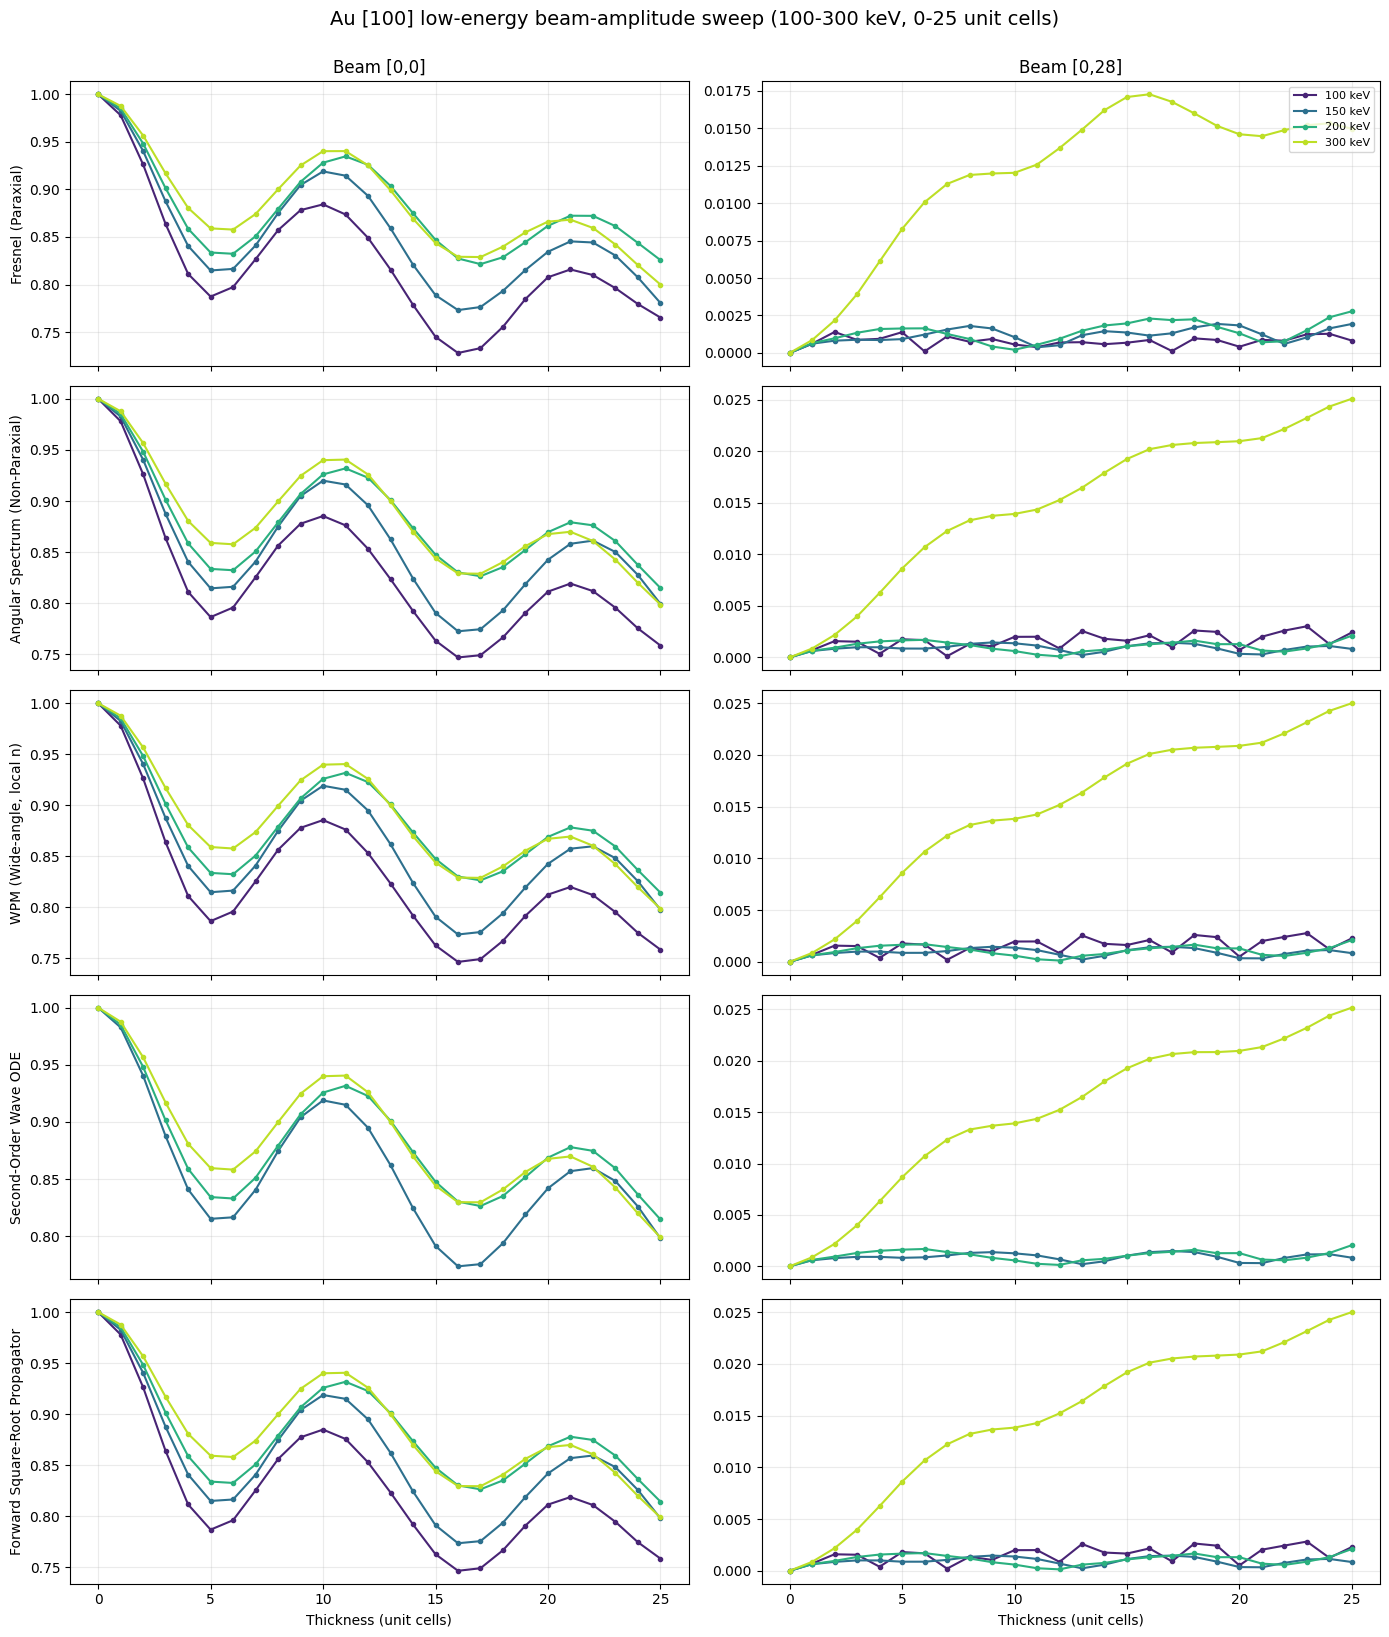

In [5]:
methods = list(display_names.keys())

energy_colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(energy_grid_kev)))

output_dir = resolve_output_dir()



fig, axes = plt.subplots(len(methods), 2, figsize=(14, 3.4 * len(methods)), sharex=True)



for row, method in enumerate(methods):

    ax_left = axes[row, 0]

    ax_right = axes[row, 1]



    for color, energy_kev in zip(energy_colors, energy_grid_kev):

        result = energy_results[float(energy_kev)]

        beam_00, beam_028 = result['curves'][method]

        ax_left.plot(x, beam_00, '-o', color=color, ms=3, lw=1.5, label=f"{energy_kev:.0f} keV")

        ax_right.plot(x, beam_028, '-o', color=color, ms=3, lw=1.5, label=f"{energy_kev:.0f} keV")



    ax_left.set_ylabel(display_names[method])

    ax_left.grid(True, alpha=0.25)

    ax_right.grid(True, alpha=0.25)



axes[0, 0].set_title('Beam [0,0]')

axes[0, 1].set_title('Beam [0,28]')

axes[-1, 0].set_xlabel('Thickness (unit cells)')

axes[-1, 1].set_xlabel('Thickness (unit cells)')

axes[0, 1].legend(loc='upper right', fontsize=8)



fig.suptitle('Au [100] low-energy beam-amplitude sweep (100-300 keV, 0-25 unit cells)', fontsize=14)

fig.tight_layout(rect=(0, 0.02, 1, 0.98))



png_path = output_dir / 'Au_low_energy_sweep_100_300keV.png'

fig.savefig(png_path, dpi=250, bbox_inches='tight')

print(f"Saved -> {png_path}")

plt.show()

Saved -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/verification/figures/Au_low_energy_sweep_028_method_comparison.png


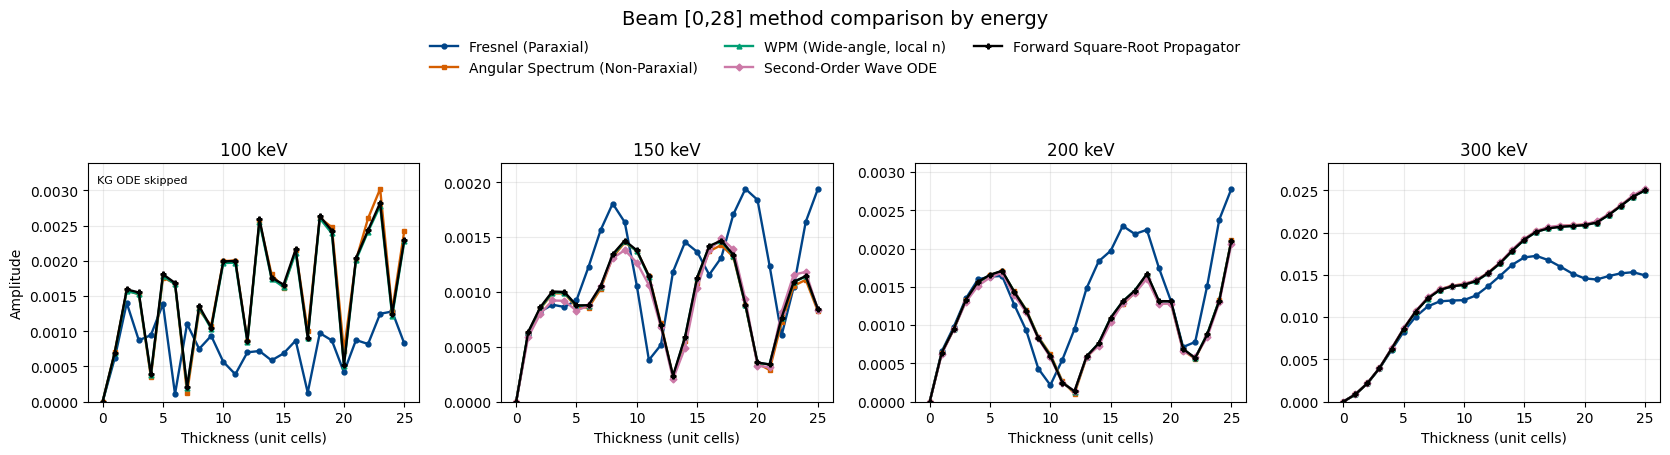

In [13]:
comparison_markers = {



    "Fresnel MS": "o",



    "Angular Spectrum MS": "s",



    "WPM": "^",



    "Full KG ODE": "D",



    "KG FWD": "P",



}







fig_028, axes_028 = plt.subplots(1, len(energy_grid_kev), figsize=(4.2 * len(energy_grid_kev), 4.6), sharex=True)







for column, energy_kev in enumerate(energy_grid_kev):



    result = energy_results[float(energy_kev)]



    ax = axes_028[column]



    finite_curves = []







    for method in methods:



        beam_028 = np.asarray(result['curves'][method][1], dtype=float)



        marker = comparison_markers[method]



        color = method_colors[method]



        label = display_names[method]







        ax.plot(x, beam_028, '-', color=color, lw=1.7, marker=marker, ms=3.5, label=label)







        finite = beam_028[np.isfinite(beam_028)]



        if finite.size:



            finite_curves.append(finite)







    if finite_curves:



        merged = np.concatenate(finite_curves)



        y_min = float(np.min(merged))



        y_max = float(np.max(merged))



        pad = 0.12 * max(y_max - y_min, 1e-4)



        ax.set_ylim(max(0.0, y_min - pad), y_max + pad)







    ax.set_title(f"{energy_kev:.0f} keV")



    ax.grid(True, alpha=0.25)



    ax.set_xlabel('Thickness (unit cells)')







    if not result['kg_ode_enabled']:



        ax.text(0.03, 0.95, 'KG ODE skipped', transform=ax.transAxes, ha='left', va='top', fontsize=8)







axes_028[0].set_ylabel('Amplitude')







handles, labels = axes_028[0].get_legend_handles_labels()



fig_028.suptitle('Beam [0,28] method comparison by energy', fontsize=14, y=0.98)



fig_028.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.94), fontsize=10)



fig_028.tight_layout(rect=(0, 0, 1, 0.80))







png_path_028 = output_dir / 'Au_low_energy_sweep_028_method_comparison.png'



fig_028.savefig(png_path_028, dpi=250, bbox_inches='tight')







print(f"Saved -> {png_path_028}")







plt.show()

## Dedicated [0,28] comparison







This reorganizes the same [0,28] beam data by energy so the methods can be compared directly in a single row.

## Final amplitudes at 25 unit cells

This is a compact numerical summary of the last point in each curve.

In [6]:
target_idx = len(n_cells_range) - 1
print(f"Final amplitudes at {x[target_idx]:.0f} unit cells")
print(f"{'Energy':>8s} {'Method':<35s} {'[0,0]':>12s} {'[0,28]':>12s}")
print('-' * 73)

for energy_kev in energy_grid_kev:
    result = energy_results[float(energy_kev)]
    for method in methods:
        beam_00, beam_028 = result['curves'][method]
        print(
            f"{energy_kev:>6.0f}keV {display_names[method]:<35s} "
            f"{beam_00[target_idx]:>12.6f} {beam_028[target_idx]:>12.6f}"
        )
    print('-' * 73)

Final amplitudes at 25 unit cells
  Energy Method                                     [0,0]       [0,28]
-------------------------------------------------------------------------
   100keV Fresnel (Paraxial)                      0.765353     0.000827
   100keV Angular Spectrum (Non-Paraxial)         0.758701     0.002424
   100keV WPM (Wide-angle, local n)               0.758642     0.002275
   100keV Second-Order Wave ODE                        nan          nan
   100keV Forward Square-Root Propagator          0.758573     0.002297
-------------------------------------------------------------------------
   150keV Fresnel (Paraxial)                      0.780665     0.001937
   150keV Angular Spectrum (Non-Paraxial)         0.799488     0.000826
   150keV WPM (Wide-angle, local n)               0.797747     0.000845
   150keV Second-Order Wave ODE                   0.798166     0.000840
   150keV Forward Square-Root Propagator          0.797956     0.000847
---------------------------